In [1]:
import numpy as np
import pandas as pd
import glob
import os
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.io import ascii
from astropy.table import Table
import itertools
from astroquery.simbad import Simbad
from utils import PLOT_PARAMS
from astropy import constants as const
from matplotlib import colors
PLOT_PARAMS()
import thejoker as tj
import random
random.seed(42) 
from scipy.stats import gaussian_kde


from datetime import date
today=date.today()
DATE =today.strftime("%m_%d_%y")
print(DATE)
import pickle
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

plt.rcParams['figure.facecolor'] = 'white'
import warnings
warnings.filterwarnings("ignore")
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u

vlt = EarthLocation.of_site('paranal')  # the easiest way... but requires internet

08_11_26


In [69]:
galah_vac = Table.read('../../lithium/data/GALAH_DR3_VAC_ages_v2.fits').to_pandas()

In [70]:
rv_df   = pd.read_csv('rv_df_new.csv')
rv_df   = pd.merge(rv_df, galah_vac[['sobject_id','m_act_bstep']],left_on='sobject_id', right_on='sobject_id')
comb_df = pd.read_csv('combined_rvs_new.csv')

In [3]:
# checked https://vizier.cds.unistra.fr/viz-bin/VizieR-3?-source=I/355/paramp 
# and Rad = radius_gspphot

gaia_xmatch = pd.read_csv('sample_gaia_crossmatch.csv')


In [73]:
merged = pd.merge(gaia_xmatch, rv_df, left_on='sobject_id', right_on='sobject_id',suffixes = ('_gaia','_galah'))

Text(0, 0.5, 'logg galah dr3')

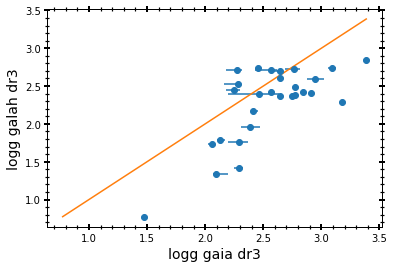

In [31]:
plt.errorbar(merged.logg_gaia, merged.logg_galah,xerr=[merged.logg_gaia-merged.b_logg_x,merged.B_logg_xa-merged.logg_gaia],fmt='o')
line = np.linspace(min(merged.logg_galah),max(merged.logg_gaia),1000)
plt.plot(line,line)
plt.xlabel('logg gaia dr3')
plt.ylabel('logg galah dr3')


Text(0, 0.5, 'radius-flame')

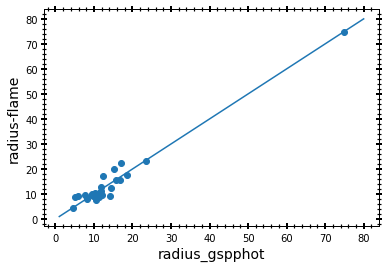

In [32]:
line = np.linspace(1,80,1000)
plt.scatter(merged.Rad,merged['Rad-Flame'])
plt.plot(line,line)
plt.xlabel('radius_gspphot')
plt.ylabel('radius-flame')

23 targets with both GALAH DR3 and GAIA-FLAME masses.
mean diff: 1.72 +/- 0.257
med diff: 1.59 +/- 0.257


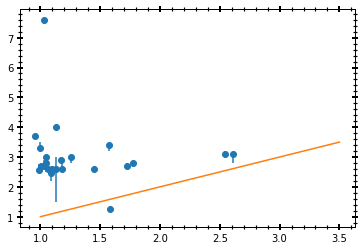

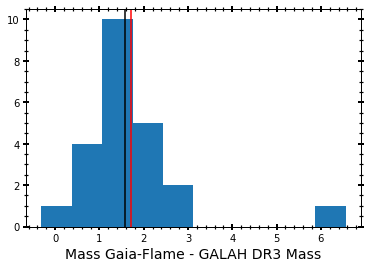

In [97]:
def mass_nonbin():
    '''
    compare flame and galah masses for non-binaries
    '''
    
    
    df = merged[~merged.sobject_id.isin(table4.sobject_id)]
    
    x1  =   df['Mass-Flame']-df['b_Mass-Flame_x']
    x2  = -(df['Mass-Flame']-df['B_Mass-Flame_xa'])

    plt.figure()
    plt.errorbar(df['m_act_bstep'],df['Mass-Flame'],yerr=[x1,x2],fmt='o')
    line = np.linspace(1,3.5,1000)
    plt.plot(line,line)

    diff = df['Mass-Flame']-df['m_act_bstep']
    count = df['Mass-Flame'].count()
    print(count,'targets with both GALAH DR3 and GAIA-FLAME masses.')
    plt.figure()
    plt.hist(diff)
    plt.xlabel('Mass Gaia-Flame - GALAH DR3 Mass')

    mean_diff = np.nanmean(diff)
    med_diff  = np.nanmedian(diff)

    print('mean diff: %.2f +/- %.3f'%(mean_diff,np.nanstd(diff)/np.sqrt(count)))
    print('med diff: %.2f +/- %.3f'%(med_diff,np.nanstd(diff)/np.sqrt(count)))
    plt.axvline(mean_diff,c='r')
    plt.axvline(med_diff,c='k')
    
mass_nonbin()

0.5 1.25 23
1.5 1.25 25


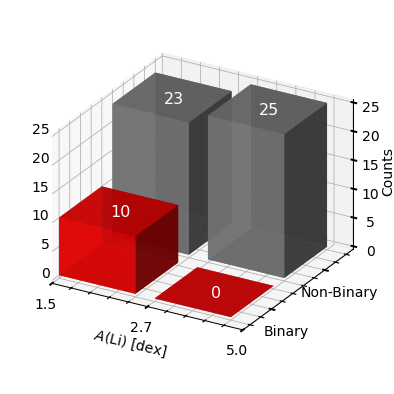

In [205]:
def make_3d_hist():
    '''
    '''
    binary    = rv_df[rv_df.sobject_id.isin(table4.sobject_id)]
    notbin    = rv_df[~rv_df.sobject_id.isin(table4.sobject_id)]
    threshold = 2.7
    
    binary_below = binary[binary.Li_val <  threshold].Li_val
    binary_above = binary[binary.Li_val >= threshold].Li_val
    notbin_below = notbin[notbin.Li_val <  threshold].Li_val
    notbin_above = notbin[notbin.Li_val >= threshold].Li_val
    
    # Lithium bin edges
    li_bins = np.array([1.5, 2.7, 5.0])
    
    # Centers used for plotting equal-width bars
    li_centers = np.array([
        (1.5 + 2.7) / 2,
        (2.7 + 5.0) / 2
    ])

    # Counts for each dataset
    counts_B = np.array([len(binary_below), len(binary_above)]) #binary
    counts_NB = np.array([len(notbin_below), len(notbin_above)]) #not binary
    
    # --------------------------------------------------
    # ARTIFICIAL X COORDINATES
    # --------------------------------------------------

    # We want two equal-width bins:
    # Bin 1: x = 0 to 1
    # Bin 2: x = 1 to 2

    x = np.array([0, 1])
    dx = 0.8

    # Dataset/depth direction
    y_B = 0
    y_NB = 1
    dy = 0.8

    # --------------------------------------------------
    # PLOT
    # --------------------------------------------------

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Binary
    ax.bar3d(
        x,
        np.full(2, y_B),
        np.zeros(2),
        dx,
        dy,
        counts_B,
        alpha=0.8,
        color='red'
    )

    # Non-Binary
    ax.bar3d(
        x,
        np.full(2, y_NB),
        np.zeros(2),
        dx,
        dy,
        counts_NB,
        alpha=0.8,
        color='grey'
    )


    # --------------------------------------------------
    # AXES
    # --------------------------------------------------

    ax.set_xlabel(r'$A(\mathrm{Li})$ [dex]', labelpad=10)
    ax.set_zlabel('Counts', labelpad=2)
    #ax.set_ylabel('Dataset', labelpad=10)
    

    # Dataset labels
    ax.set_yticks([
        y_B + dy/2,
        y_NB + dy/2
    ])
    
    # --------------------------------------------------
    # MANUALLY LABEL THE BIN EDGES
    # --------------------------------------------------

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['1.5', '2.7', '5.0'])

    # Make the plotting range exactly the two bins
    ax.set_xlim(0, 2)

    # --------------------------------------------------
    # PROJECTION / VIEW
    # --------------------------------------------------

    ax.set_proj_type('ortho')
    
    # Viewing angle
    ax.view_init(elev=25, azim=-60) #azim=-60, or 45
    
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='z', labelsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # --------------------------------------------------
    # Duplicate zticks 
    # --------------------------------------------------

    zticks = ax.get_zticks()
    zticks = np.arange(0,30,5)

    for z in zticks:
        ax.text(
            -0.1,       # adjust this to move left/right
            0,           # y position
            z,           # z position
            f'{z:g}',
            ha='right',
            va='center',
            fontsize=14
        )
    ax.set_yticklabels(['Binary','Non-Binary'],rotation=0)#
    ax.tick_params(axis='y', pad=7)#,rotation=-60)

    # --------------------------------------------------
    # TEXT ON TOP OF THE BARS
    # --------------------------------------------------
    
    fontsize = 16
    
    x,y,z = [0.5,1.5],np.full(2, y_B),np.zeros(2),
    dz = counts_B
    for xi, yi, dzi in zip(x, y, dz):
        # Centering math: add half of dx to X, half of dy to Y
        label_x = xi #+ (0.5 * 0.5) 
        label_y = yi + (0.5 * 0.5)
        # The height is exactly where the bar ends (dzi)
        label_z = dzi                  
        ax.text(
            label_x, 
            label_y, 
            label_z, 
            str(dzi),                  # The text string to display
            ha='center',               # Horizontal alignment
            va='bottom',               # Vertical alignment (sits above the point)
            color='white', 
            fontsize=fontsize
        )
        
    dz = counts_NB
    y  = np.full(2,y_NB)
    
    for xi, yi, dzi in zip(x, y, dz):
        # Centering math: add half of dx to X, half of dy to Y
        label_x = xi #+ (0.5 * 0.5) 
        label_y = yi + (0.5 * 0.5)
        # The height is exactly where the bar ends (dzi)
        label_z = dzi                  
        print(label_x,label_y,label_z)
        ax.text(
            label_x, 
            label_y, 
            label_z, 
            str(dzi),                  # The text string to display
            ha='center',               # Horizontal alignment
            va='bottom',               # Vertical alignment (sits above the point)
            color='white', 
            fontsize=fontsize
        )
    
    ax.set_box_aspect(None, zoom=0.9)
    plt.tight_layout()
    plt.show()
make_3d_hist()

In [53]:
table4   = pd.read_csv('table4_new.csv')
binaries = merged[merged.sobject_id.isin(table4.sobject_id)]
binaries = pd.merge(merged, table4, left_on='sobject_id',right_on='sobject_id')
binaries

,col1,sobject_id,ra_dr2_gaia,dec_dr2_gaia,Source,RAdeg,DEdeg,PQSO,PGal,Pstar,...,use_rv_flag_y,esp_time_y,esp_rv_y,esp_rv_err_y,m_act_bstep,e_m_act_bstep,radius_bstep,e_radius_bstep,v_max,v_orb
0,4,150829004301285,322.355161,-40.148731,6579575475802939392,322.355161,-40.148733,0.0,0.0,0.999985,...,0,[2460286.52633312 2460271.50561348 2460252.504...,[-2.97596293 -2.49940061 -1.67224661],[0.00886087 0.00525793 0.00573923],1.667217,0.532714,12.654351,0.909996,NaN,NaN
1,5,160129003601260,94.995058,-27.337157,2899390245231066880,94.995058,-27.337157,0.0,0.0,0.999960,...,0,[2460299.52610808 2460272.60059796 2460327.520...,[3.11909891 3.08054002 2.88418409 3.56078024 3...,[0.02489859 0.01818485 0.01967496 0.035769 0...,1.888812,0.064000,8.013299,0.206622,NaN,NaN
2,7,170514002101318,158.810584,-70.515286,5232071641786703488,158.810578,-70.515285,0.0,0.0,0.999890,...,0,[2460388.50479575 2460348.87299403 2460364.882...,[-1.86912108 3.32658486 -9.46735817],[0.00663089 0.00837487 0.01975791],1.796318,0.264294,12.867594,0.084008,NaN,NaN
3,16,140707003101315,337.265875,-6.423480,2622883652325300992,337.265875,-6.423481,0.0,0.0,0.999974,...,0,[2460473.87834479 2460458.85018411 2460534.673...,[-44.4442598 -44.50548853 -44.12095429 -44.43...,[0.05024103 0.05054062 0.06273943 0.04256826 0...,0.956547,0.093214,5.307757,0.139619,NaN,NaN
4,18,170509005201208,258.746905,-18.252141,4134444748741183488,258.746904,-18.252142,0.0,0.0,0.999976,...,0,[2460504.52312549 2460547.5883764 2460476.573...,[69.94735172 69.93045306 69.53730788 70.354179...,[0.06402008 0.06986536 0.10496806 0.08084854 0...,1.985078,0.050308,8.683977,0.137897,NaN,NaN
5,23,170418005701333,279.215264,-45.982592,6708750736102048256,279.215264,-45.982593,0.0,0.0,0.999973,...,0,[2460453.74225422 2460488.88720792 2460473.801...,[39.52938069 43.76718993 22.84001243 15.233563...,[0.10111777 0.11187892 0.08341896 0.08657685 0...,1.243245,0.177130,7.190328,0.126351,119.587010,95.014641
6,25,170801002501304,237.890929,-69.703209,5819206285484386304,237.890925,-69.703210,0.0,0.0,0.999978,...,0,[2460515.54535378 2460435.70137357 2460499.701...,[-47.9155846 -37.1433239 -42.11636955 -14.19...,[0.0904714 0.02237316 0.02173481 0.02801057 0...,1.611008,0.413294,11.531145,0.141572,209.198073,163.762521
7,26,170615003401088,242.713406,-70.185457,5819262532372445056,242.713403,-70.185459,0.0,0.0,0.999975,...,0,[2460473.82536318 2460435.72400521 2460516.567...,[-34.03070487 -33.89898871 -32.97725796 -30.99...,[0.079425 0.07317809 0.08947075 0.07722614 0...,1.058158,0.118000,10.679730,0.167917,NaN,NaN
8,30,160524006101130,301.879542,-45.352293,6673373227923805312,301.879542,-45.352293,0.0,0.0,0.999969,...,0,[2460506.58668542 2460455.81590345 2460473.857...,[16.29001445 14.58151513 14.97103738 17.341919...,[0.01512158 0.02215834 0.0117491 0.01486014 0...,1.728874,0.283500,8.011563,0.255235,NaN,NaN
9,49,140209002201006,117.563465,-57.613481,5295277759201045120,117.563465,-57.613481,0.0,0.0,0.999998,...,0,[2461083.70037147 2461000.77425049 2461098.718...,[159.86698945 159.8316715 159.65277609 159.92...,[0.07179552 0.06728325 0.06622799 0.06508453 0...,1.592433,0.462500,9.358593,0.823714,NaN,NaN


5

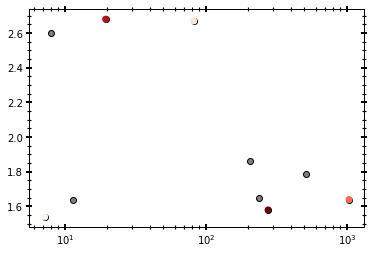

In [55]:
plt.scatter(table4.Mj50,table4.Li_val,fc='grey',ec='k')
plt.scatter(binaries.Mj50,binaries.Li_val_x,c=binaries.Rad,cmap='Reds')
plt.xscale('log')

# binaries['Rad'].count()
# binaries['sobject_id'].count()

def get_mass():
    '''
    @input: 
        Rad :
        logg_galah :
    '''


In [59]:
for i in merged.keys():
    print(i)

col1
sobject_id
ra_dr2_gaia
dec_dr2_gaia
Source
RAdeg
DEdeg
PQSO
PGal
Pstar
PWD
Pbin
PQSO-S
Pgal-S
Pstar-S
PWD-S
Pbin-S
PQSO-A
PGal-A
Pstar-A
Teff
b_Teff_x
B_Teff_xa
logg_gaia
b_logg_x
B_logg_xa
[Fe/H]
b_[Fe/H]_x
B_[Fe/H]_xa
Dist
b_Dist_x
B_Dist_xa
A0
b_A0_x
B_A0_xa
AG
b_AG_x
B_AG_xa
ABP
b_ABP_x
B_ABP_xa
ARP
b_ARP_x
B_ARP_xa
E(BP-RP)
b_E(BP-RP)_x
B_E(BP-RP)_xa
GMAG
b_GMAG_x
B_GMAG_xa
Rad
b_Rad_x
B_Rad_xa
logpost
Accp
Lib
Teff-S
b_Teff-S_x
B_Teff-S_xa
logg-S
b_logg-S_x
B_logg-S_xa
[M/H]-S
b_[M/H]-S_x
B_[M/H]-S_xa
[alpha/Fe]-S
b_[alpha/Fe]-S_x
B_[alpha/Fe]-S_xa
[Fe/H]-S
b_[Fe/H]-S_x
B_[Fe/H]-S_xa
o_[Fe/H]-S
s_[Fe/H]-S
[Si/Fe]-S
b_[Si/Fe]-S_x
B_[Si/Fe]-S_xa
o_[Si/Fe]-S
s_[Si/Fe]-S
[Ca/Fe]-S
b_[Ca/Fe]-S_x
B_[Ca/Fe]-S_xa
o_[Ca/Fe]-S
s_[Ca/Fe]-S
[Ti/Fe]-S
b_[Ti/Fe]-S_x
B_[Ti/Fe]-S_xa
o_[Ti/Fe]-S
s_[Ti/Fe]-S
[Mg/Fe]-S
b_[Mg/Fe]-S_x
B_[Mg/Fe]-S_xa
[Nd/Fe]-S
b_[Nd/Fe]-S_x
B_[Nd/Fe]-S_xa
[FeII/M]-S
b_[FeII/M]-S_x
B_[FeII/M]-S_xa
[S/Fe]-S
b_[S/Fe]-S_x
B_[S/Fe]-S_xa
o_[S/Fe]-S
s_[S/Fe]-S
[Zr/Fe]-S